In [1]:
import sys, pathlib
project_root = pathlib.Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trader.l2_features import build_bt_df
from trader.l3_regime import efficiency_ratio, forward_regime_label

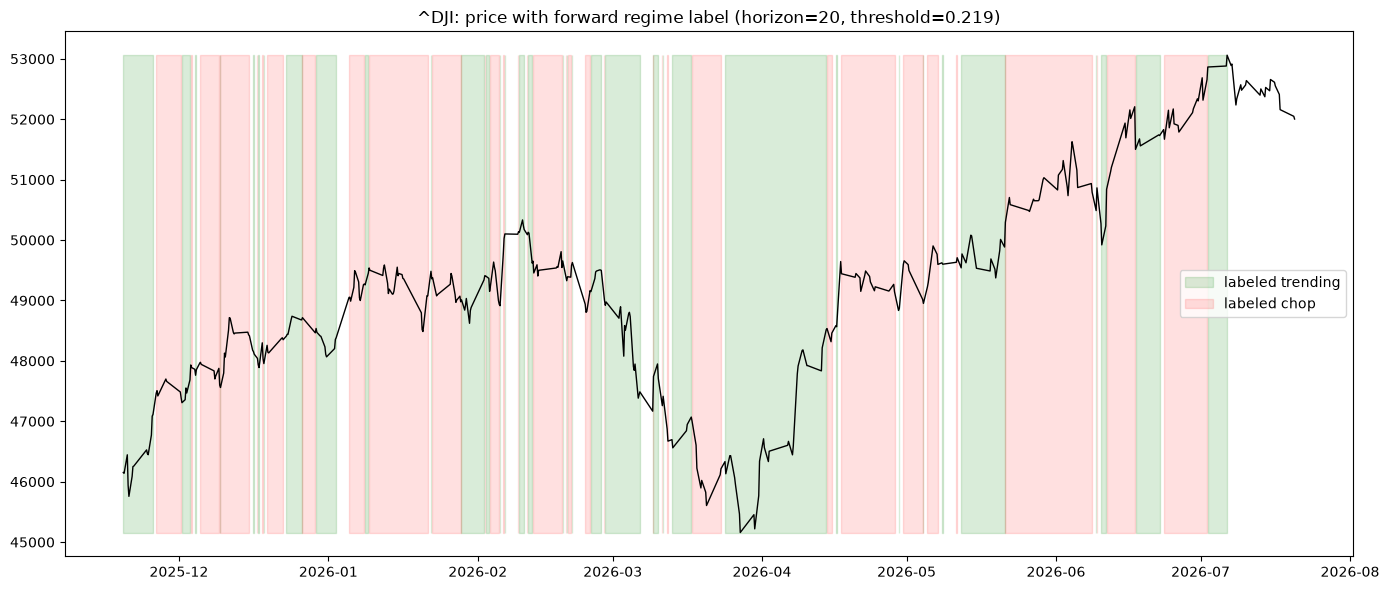

Label distribution: {0.0: 844, 1.0: 843}  (NaN = last 20 bars, unlabeled)


In [3]:
symbol = "^DJI"  # US30 - the instrument where we diagnosed the whipsaw problem
df = build_bt_df(symbol)

horizon = 20      # bars ahead to judge "was this actually a trend" (matches swing_lookback scale)
threshold = 0.219  # efficiency ratio cutoff for calling it trending

label = forward_regime_label(df["Close"], horizon=horizon, threshold=threshold)

# recent, readable slice - the full ~1700-bar history would be unreadable as one plot
window = df.iloc[-400:].copy()
window["label"] = label.reindex(window.index)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(window.index, window["Close"], color="black", linewidth=1)

ymin, ymax = window["Close"].min(), window["Close"].max()
trending_mask = window["label"] == 1.0
choppy_mask = window["label"] == 0.0

ax.fill_between(window.index, ymin, ymax, where=trending_mask, color="green", alpha=0.15, step="pre", label="labeled trending")
ax.fill_between(window.index, ymin, ymax, where=choppy_mask, color="red", alpha=0.12, step="pre", label="labeled chop")

ax.set_title(f"{symbol}: price with forward regime label (horizon={horizon}, threshold={threshold})")
ax.legend()
plt.tight_layout()
plt.show()

print("Label distribution:", label.value_counts(dropna=True).to_dict(), f" (NaN = last {horizon} bars, unlabeled)")

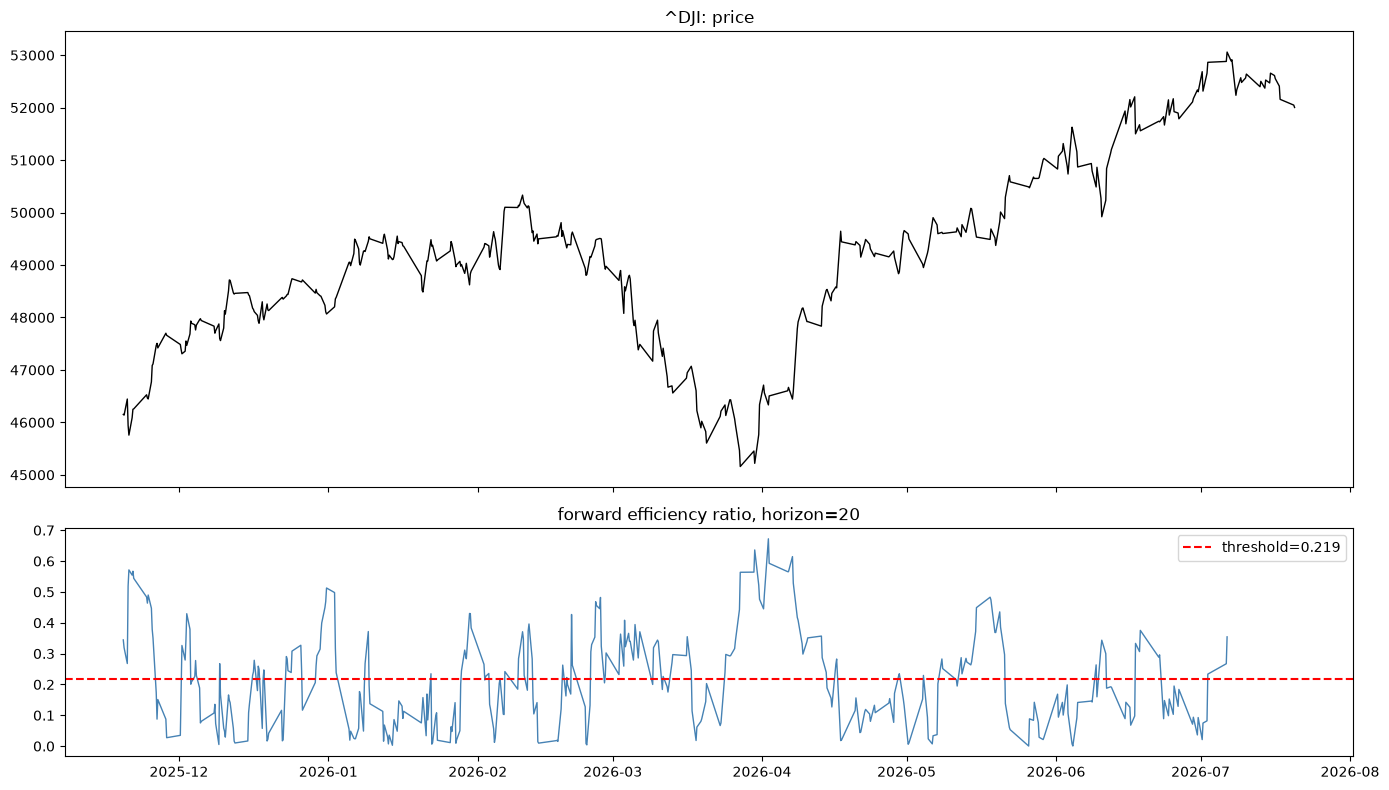

In [4]:

fwd_net = (df["Close"].shift(-horizon) - df["Close"]).abs()
fwd_path = df["Close"].diff().abs().rolling(horizon).sum().shift(-horizon)
fwd_er_raw = fwd_net / fwd_path

window["fwd_er_raw"] = fwd_er_raw.reindex(window.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(window.index, window["Close"], color="black", linewidth=1)
ax1.set_title(f"{symbol}: price")

ax2.plot(window.index, window["fwd_er_raw"], color="steelblue", linewidth=1)
ax2.axhline(threshold, color="red", linestyle="--", label=f"threshold={threshold}")
ax2.set_title(f"forward efficiency ratio, horizon={horizon}")
ax2.legend()
plt.tight_layout()
plt.show()

horizon=20: median=0.219  mean=0.258  p60=0.279  p70=0.341  p75=0.370
horizon=40: median=0.165  mean=0.190  p60=0.198  p70=0.235  p75=0.259


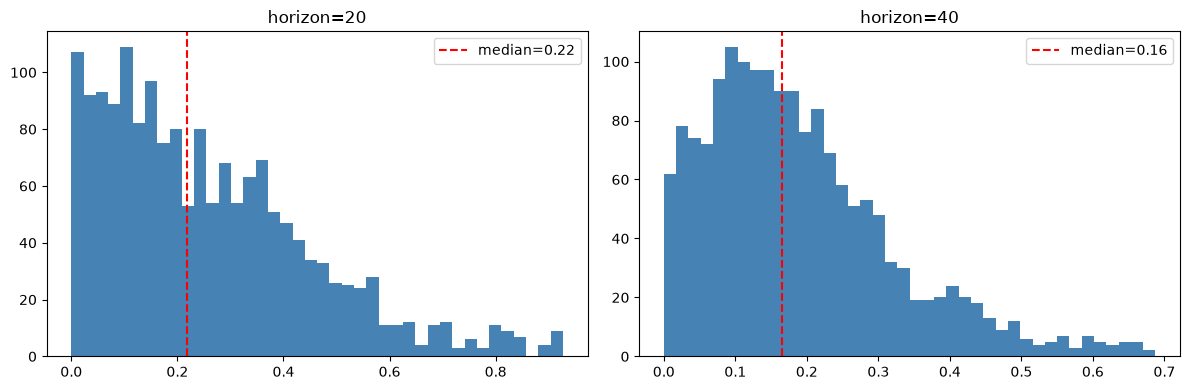

In [5]:
for h in [20, 40]:
    fwd_net = (df["Close"].shift(-h) - df["Close"]).abs()
    fwd_path = df["Close"].diff().abs().rolling(h).sum().shift(-h)
    fwd_er = (fwd_net / fwd_path).dropna()
    print(f"horizon={h}: median={fwd_er.median():.3f}  mean={fwd_er.mean():.3f}  "
          f"p60={fwd_er.quantile(0.6):.3f}  p70={fwd_er.quantile(0.7):.3f}  p75={fwd_er.quantile(0.75):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h in zip(axes, [20, 40]):
    fwd_net = (df["Close"].shift(-h) - df["Close"]).abs()
    fwd_path = df["Close"].diff().abs().rolling(h).sum().shift(-h)
    fwd_er = (fwd_net / fwd_path).dropna()
    ax.hist(fwd_er, bins=40, color="steelblue")
    ax.axvline(fwd_er.median(), color="red", linestyle="--", label=f"median={fwd_er.median():.2f}")
    ax.set_title(f"horizon={h}")
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
from trader.l3_regime import build_regime_features

features = build_regime_features(df)
features["label"] = label  # the horizon=20, threshold=0.219 label from before

check = features.dropna().groupby("label").mean()
print(check.T)

label                         0.0        1.0
adx_14                  24.741667  22.927546
er_20                    0.271656   0.213613
atr_expansion_50         1.030672   1.020374
ema_crossover_count_20   0.920882   1.162123
ma200_slope_20           0.004762   0.004625


In [7]:
from scipy.stats import mannwhitneyu

feature_cols = ["adx_14", "er_20", "atr_expansion_50", "ema_crossover_count_20", "ma200_slope_20"]
clean = features.dropna()

for col in feature_cols:
    chop_vals = clean.loc[clean["label"] == 0.0, col]
    trend_vals = clean.loc[clean["label"] == 1.0, col]
    stat, p = mannwhitneyu(trend_vals, chop_vals, alternative="two-sided")
    auc = stat / (len(trend_vals) * len(chop_vals))
    print(f"{col:25s}  p={p:.4f}  trend-vs-chop AUC={auc:.3f}  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)")

adx_14                     p=0.0000  trend-vs-chop AUC=0.438  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)
er_20                      p=0.0000  trend-vs-chop AUC=0.409  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)
atr_expansion_50           p=0.6294  trend-vs-chop AUC=0.493  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)
ema_crossover_count_20     p=0.0000  trend-vs-chop AUC=0.577  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)
ma200_slope_20             p=0.8929  trend-vs-chop AUC=0.502  (0.5=no separation, >0.5=trend higher, <0.5=trend lower)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

feature_cols = ["adx_14", "er_20", "ema_crossover_count_20"]  # the two dead features dropped
data = features[feature_cols + ["label"]].dropna()

def regime_walk_forward(data, feature_cols, initial_train_months=12, test_months=3):
    data_start = data.index[0]
    data_end = data.index[-1]
    train_end = data_start + pd.DateOffset(months=initial_train_months)

    fold_results = []
    oos_probs, oos_true = [], []

    while train_end + pd.DateOffset(months=test_months) <= data_end:
        test_end = train_end + pd.DateOffset(months=test_months)

        train_slice = data.loc[data_start:train_end]
        test_slice = data.loc[train_end:test_end]

        X_train, y_train = train_slice[feature_cols], train_slice["label"]
        X_test, y_test = test_slice[feature_cols], test_slice["label"]

        if y_train.nunique() < 2 or y_test.nunique() < 2 or len(X_test) < 5:
            train_end = test_end
            continue

        model = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced"))
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_test)[:, 1]
        fold_auc = roc_auc_score(y_test, probs)

        fold_results.append({"test_end": test_end, "n_test": len(X_test), "auc": fold_auc})
        print(f"Fold test [{train_end.date()} -> {test_end.date()}]  n={len(X_test)}  AUC={fold_auc:.3f}")

        oos_probs.extend(probs)
        oos_true.extend(y_test.values)
        train_end = test_end

    pooled_auc = roc_auc_score(oos_true, oos_probs)
    return pd.DataFrame(fold_results), pooled_auc

fold_df, pooled_auc = regime_walk_forward(data, feature_cols)
print(fold_df)
print(f"\nPooled out-of-sample AUC across all folds: {pooled_auc:.3f}")
print("(single-feature ceiling was ema_crossover_count_20 at 0.577)")

Fold test [2024-09-08 -> 2024-12-08]  n=151  AUC=0.439
Fold test [2024-12-08 -> 2025-03-08]  n=179  AUC=0.462
Fold test [2025-03-08 -> 2025-06-08]  n=126  AUC=0.636
Fold test [2025-06-08 -> 2025-09-08]  n=124  AUC=0.827
Fold test [2025-09-08 -> 2025-12-08]  n=152  AUC=0.581
Fold test [2025-12-08 -> 2026-03-08]  n=181  AUC=0.591
Fold test [2026-03-08 -> 2026-06-08]  n=127  AUC=0.747
                   test_end  n_test       auc
0 2024-12-08 08:00:00-05:00     151  0.438581
1 2025-03-08 08:00:00-05:00     179  0.461772
2 2025-06-08 08:00:00-04:00     126  0.635823
3 2025-09-08 08:00:00-04:00     124  0.827325
4 2025-12-08 08:00:00-05:00     152  0.580908
5 2026-03-08 08:00:00-04:00     181  0.590784
6 2026-06-08 08:00:00-04:00     127  0.747264

Pooled out-of-sample AUC across all folds: 0.533
(single-feature ceiling was ema_crossover_count_20 at 0.577)


In [9]:
feature_cols_single = ["ema_crossover_count_20"]
data_single = features[feature_cols_single + ["label"]].dropna()

fold_df_single, pooled_auc_single = regime_walk_forward(data_single, feature_cols_single)
print(fold_df_single)
print(f"\nPooled out-of-sample AUC (crossover count alone): {pooled_auc_single:.3f}")

Fold test [2024-09-01 -> 2024-12-01]  n=144  AUC=0.476
Fold test [2024-12-01 -> 2025-03-01]  n=179  AUC=0.554
Fold test [2025-03-01 -> 2025-06-01]  n=131  AUC=0.642
Fold test [2025-06-01 -> 2025-09-01]  n=125  AUC=0.544
Fold test [2025-09-01 -> 2025-12-01]  n=146  AUC=0.605
Fold test [2025-12-01 -> 2026-03-01]  n=180  AUC=0.567
Fold test [2026-03-01 -> 2026-06-01]  n=133  AUC=0.679
                   test_end  n_test       auc
0 2024-12-01 12:00:00-05:00     144  0.475645
1 2025-03-01 12:00:00-05:00     179  0.553911
2 2025-06-01 12:00:00-04:00     131  0.642185
3 2025-09-01 12:00:00-04:00     125  0.544257
4 2025-12-01 12:00:00-05:00     146  0.604511
5 2026-03-01 12:00:00-05:00     180  0.567403
6 2026-06-01 12:00:00-04:00     133  0.678851

Pooled out-of-sample AUC (crossover count alone): 0.522


In [10]:
gold_df = build_bt_df("GC=F")

gold_fwd_net = (gold_df["Close"].shift(-horizon) - gold_df["Close"]).abs()
gold_fwd_path = gold_df["Close"].diff().abs().rolling(horizon).sum().shift(-horizon)
gold_fwd_er = (gold_fwd_net / gold_fwd_path).dropna()

gold_threshold = gold_fwd_er.median()
print(f"Gold median forward ER (horizon={horizon}): {gold_threshold:.3f}  (US30 was {threshold:.3f})")

Gold median forward ER (horizon=20): 0.233  (US30 was 0.219)


In [11]:
us30_features = build_regime_features(df)
us30_features["label"] = forward_regime_label(df["Close"], horizon=horizon, threshold=threshold)
us30_features["symbol"] = "US30"

gold_features = build_regime_features(gold_df)
gold_features["label"] = forward_regime_label(gold_df["Close"], horizon=horizon, threshold=gold_threshold)
gold_features["symbol"] = "GOLD"

pooled = pd.concat([us30_features, gold_features]).sort_index()
print(f"Pooled rows: {len(pooled)}  (US30: {len(us30_features)}, Gold: {len(gold_features)})")

Pooled rows: 5350  (US30: 1707, Gold: 3643)


In [12]:
feature_cols_single = ["ema_crossover_count_20"]
pooled_single = pooled[feature_cols_single + ["label"]].dropna()

fold_df_pooled, pooled_auc_combined = regime_walk_forward(pooled_single, feature_cols_single)
print(fold_df_pooled)
print(f"\nPooled (US30+Gold) out-of-sample AUC, crossover count alone: {pooled_auc_combined:.3f}")
print("(US30-only was 0.522)")

Fold test [2024-09-01 -> 2024-12-01]  n=524  AUC=0.491
Fold test [2024-12-01 -> 2025-03-01]  n=553  AUC=0.514
Fold test [2025-03-01 -> 2025-06-01]  n=516  AUC=0.586
Fold test [2025-06-01 -> 2025-09-01]  n=511  AUC=0.569
Fold test [2025-09-01 -> 2025-12-01]  n=528  AUC=0.534
Fold test [2025-12-01 -> 2026-03-01]  n=548  AUC=0.441
Fold test [2026-03-01 -> 2026-06-01]  n=515  AUC=0.528
                   test_end  n_test       auc
0 2024-12-01 12:00:00-05:00     524  0.490941
1 2025-03-01 12:00:00-05:00     553  0.514081
2 2025-06-01 12:00:00-04:00     516  0.585520
3 2025-09-01 12:00:00-04:00     511  0.568818
4 2025-12-01 12:00:00-05:00     528  0.533532
5 2026-03-01 12:00:00-05:00     548  0.441095
6 2026-06-01 12:00:00-04:00     515  0.527907

Pooled (US30+Gold) out-of-sample AUC, crossover count alone: 0.505
(US30-only was 0.522)
